In [1]:
!pip install -q 'git+https://github.com/facebookresearch/segment-anything.git'
!pip install -q 'git+https://github.com/bowang-lab/MedSAM.git'

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


In [2]:
# !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
# !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
# !wget --no-check-certificate "https://docs.google.com/uc?export=download&id=1UAmWL88roYR7wKlnApw5Bcuzf2iQgk6_" -O medsam_vit_b.pth
# !wget https://zenodo.org/records/10689643/files/medsam_vit_b.pth

In [3]:
# !rm -f /kaggle/working/medsam-vit-base

In [4]:
# https://drive.google.com/file/d/1UAmWL88roYR7wKlnApw5Bcuzf2iQgk6_/view?usp=sharing

In [5]:
!pip show segment-anything

Name: segment_anything
Version: 1.0
Summary: 
Home-page: 
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: 
Required-by: 


In [6]:
!pip show MedSam

Name: medsam
Version: 0.0.1
Summary: 
Home-page: 
Author: Jun Ma
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: ipympl, ipywidgets, jupyterlab, matplotlib, nibabel, opencv-python, scikit-image, scipy, SimpleITK, tqdm
Required-by: 


In [7]:
import os
import cv2
import shutil
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' 
import pandas as pd
from glob import glob
from PIL import Image
from matplotlib import pyplot as plt
import nibabel as nib
from ipywidgets import interact
import numpy as np
import plotly.graph_objects as go
import torch
import torchvision.transforms as T
from torch.utils.data import Dataset
from scipy.ndimage import label
import random
from tqdm import tqdm

# sam, medsam
from segment_anything import sam_model_registry, SamPredictor
# from utils.demo import BboxPromptDemo

In [8]:
class PolypSegmentationDataset(Dataset):
    def __init__(
        self,
        root_dir,
        dataset_type,              # "cvc" | "kvasir-polyp" | "kvasir-instrument"
        image_transform=None,
        mask_transform=None,
    ):
        self.dataset_type = dataset_type.lower()
        self.image_transform = image_transform
        self.mask_transform = mask_transform

        if self.dataset_type == "cvc":
            self.image_dir = os.path.join(root_dir, "Original")
            self.mask_dir = os.path.join(root_dir, "Ground Truth")

        elif self.dataset_type == "kvasir-polyp":
            self.image_dir = os.path.join(root_dir, "images")
            self.mask_dir = os.path.join(root_dir, "masks")

        elif self.dataset_type == "kvasir-instrument":
            self.image_dir = os.path.join(root_dir, "images", "images")
            self.mask_dir = os.path.join(root_dir, "masks", "masks")

        else:
            raise ValueError(
                "dataset_type must be: cvc | kvasir-polyp | kvasir-instrument"
            )

        self.images = sorted(os.listdir(self.image_dir))
        self.masks = sorted(os.listdir(self.mask_dir))

        assert len(self.images) == len(self.masks), "Image & mask count mismatch"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        # ---- image ----
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = torch.from_numpy(image).float().permute(2, 0, 1) / 255.0

        # ---- mask ----
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = torch.from_numpy(mask).unsqueeze(0)
        mask = (mask > 0).float()   

        if self.image_transform:
            image = self.image_transform(image)

        if self.mask_transform:
            mask = self.mask_transform(mask)

        return image, mask

In [9]:
cvc_dataset = PolypSegmentationDataset(
    root_dir="/kaggle/input/cvc-clinicdb/PNG",
    dataset_type="cvc",
    # image_transform=image_transform,
    # mask_transform=mask_transform,
)

tool_dataset = PolypSegmentationDataset(
    root_dir="/kaggle/input/kvasir-instrument/kvasir-instrument",
    dataset_type="kvasir-instrument",
    # image_transform=image_transform,
    # mask_transform=mask_transform,
)

kva_dataset = PolypSegmentationDataset(
    root_dir="/kaggle/input/kvasir-seg/Kvasir-SEG",
    dataset_type="kvasir-polyp",
    # image_transform=image_transform,
    # mask_transform=mask_transform,
)

In [10]:
image, mask = cvc_dataset[0]
tool, tool_mask = tool_dataset[0]
kva_img, kva_mask = kva_dataset[0]

In [11]:
def preprocess_rgb(image):
    """
    image: RGB numpy (H,W,3) or torch Tensor (C,H,W)
    output: uint8 numpy (H,W,3)
    """
    import torch
    import numpy as np

    if torch.is_tensor(image):
        image = image.detach().cpu().permute(1,2,0).numpy()

    if image.dtype != np.uint8:
        image = (image * 255).clip(0,255).astype(np.uint8)

    return image

def ensure_2d_mask(mask):
    import torch
    import numpy as np

    if torch.is_tensor(mask):
        mask = mask.detach().cpu().numpy()

    if mask.ndim == 3:
        mask = mask.squeeze()

    return (mask > 0).astype(np.uint8)


def mask_to_box(mask):
    mask = ensure_2d_mask(mask)
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None

    box = np.array(
        [xs.min(), ys.min(), xs.max(), ys.max()],
        dtype=np.float32
    )
    return box[None, :]   # (1, 4)

def mask_to_point(mask):
    mask = ensure_2d_mask(mask)
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    cx = xs.mean()
    cy = ys.mean()
    return np.array([[cx, cy]], dtype=np.float32)

In [12]:
def draw_box(img, mask, color=(0, 255, 0), thickness=2):
    """
    img: HWC RGB numpy OR torch Tensor (C,H,W)
    box: [x1, y1, x2, y2]
    """
    box = mask_to_box(mask)
    if box is None:
        return img

    # --- ensure numpy HWC ---
    if torch.is_tensor(img):
        img = img.detach().cpu().permute(1,2,0).numpy()

    if img.dtype != np.uint8:
        img = (img * 255).clip(0,255).astype(np.uint8)

    x1, y1, x2, y2 = box[0].astype(int)
    img = img.copy()
    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)

    return img

In [13]:
def visualize_sample(image, mask):
    image = image.permute(1, 2, 0).cpu().numpy()
    mask = mask.squeeze(0).cpu().numpy()

    img = draw_box(image, mask)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].imshow(img)
    axs[0].set_title("Image")
    axs[0].axis("off")

    axs[1].imshow(mask, cmap="gray")
    axs[1].set_title("Mask")
    axs[1].axis("off")

    axs[2].imshow(img)
    axs[2].imshow(mask, cmap="jet", alpha=0.5)
    axs[2].set_title("Overlay")
    axs[2].axis("off")

    plt.show()

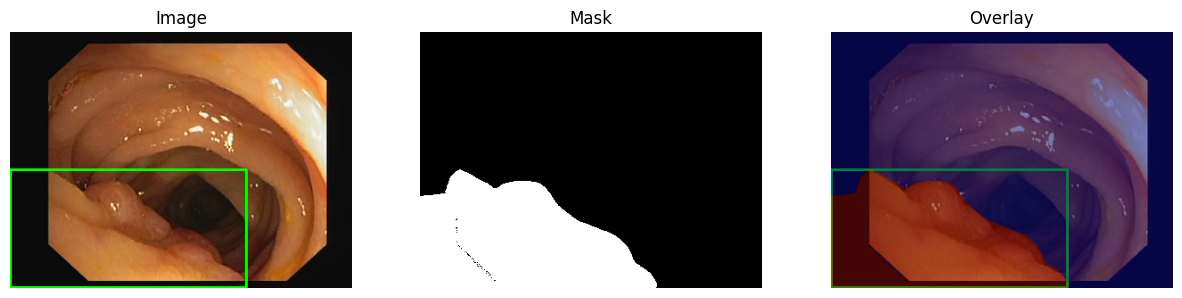

In [14]:
visualize_sample(image, mask)

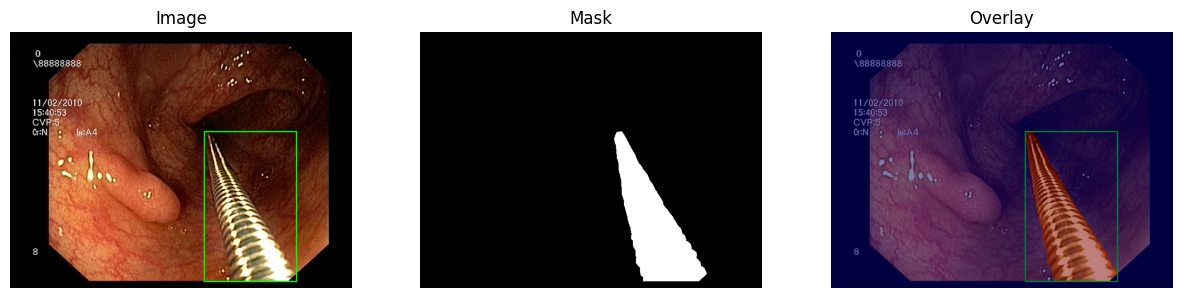

In [15]:
visualize_sample(tool, tool_mask)

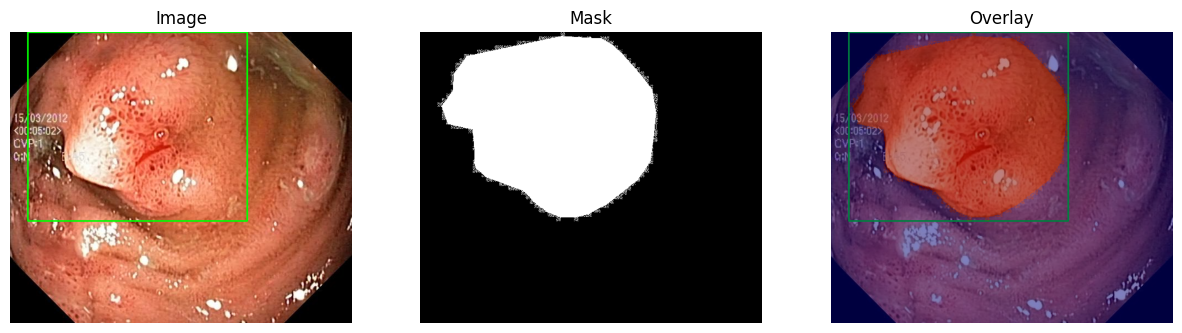

In [16]:
visualize_sample(kva_img, kva_mask)

In [17]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CHECKPOINT_PATH = "/kaggle/working/sam_vit_b_01ec64.pth"

sam = sam_model_registry["vit_b"](
    checkpoint=CHECKPOINT_PATH
).to(DEVICE)

sam.eval()
predictor = SamPredictor(sam)

In [18]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MEDSAM_CHECKPOINT_PATH = "/kaggle/working/medsam_vit_b.pth"

medsam = sam_model_registry['vit_b'](checkpoint=MEDSAM_CHECKPOINT_PATH).to(DEVICE)
medsam.eval()
med_predictor = SamPredictor(medsam)

In [19]:
image, mask = cvc_dataset[0]

gt_mask = ensure_2d_mask(mask)
image_rgb = preprocess_rgb(image)
box = mask_to_box(gt_mask)
point = mask_to_point(gt_mask)

predictor.set_image(image_rgb)

pred_masks, _, _ = predictor.predict(
    box=box,
    point_coords=point,
    point_labels=np.array([1]),
    multimask_output=False
)

In [20]:
kva_img, kva_mask = kva_dataset[0]

gt_kva_mask = ensure_2d_mask(kva_mask)
image_rgb = preprocess_rgb(kva_img)
box = mask_to_box(gt_kva_mask)
point = mask_to_point(gt_kva_mask)

predictor.set_image(image_rgb)

pred_kva_masks, _, _ = predictor.predict(
    box=box,
    point_coords=point,
    point_labels=np.array([1]),
    multimask_output=False
)

In [21]:
image, mask = cvc_dataset[0]

gt_mask = ensure_2d_mask(mask)
image_rgb = preprocess_rgb(image)
box = mask_to_box(gt_mask)
point = mask_to_point(gt_mask)

med_predictor.set_image(image_rgb)

pred_masks, _, _ = med_predictor.predict(
    box=box,
    point_coords=None,
    point_labels=None,
    multimask_output=False
)

kva_img, kva_mask = kva_dataset[0]

gt_kva_mask = ensure_2d_mask(kva_mask)
kva_image_rgb = preprocess_rgb(kva_img)
box = mask_to_box(gt_kva_mask)
point = mask_to_point(gt_kva_mask)

med_predictor.set_image(kva_image_rgb)

pred_kva_masks, _, _ = med_predictor.predict(
    box=box,
    point_coords=None,
    point_labels=None,
    multimask_output=False
)

In [22]:
def visualize_pred(image, mask, pred_mask):
    image = image.permute(1, 2, 0).cpu().numpy()
    mask = mask.squeeze(0).cpu().numpy()

    img = draw_box(image, mask)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].imshow(img)
    axs[0].set_title("Image")
    axs[0].axis("off")

    axs[1].imshow(mask, cmap="gray")
    axs[1].set_title("Mask")
    axs[1].axis("off")

    axs[2].imshow(pred_mask, cmap="gray")
    axs[2].set_title("Mask")
    axs[2].axis("off")

    plt.show()

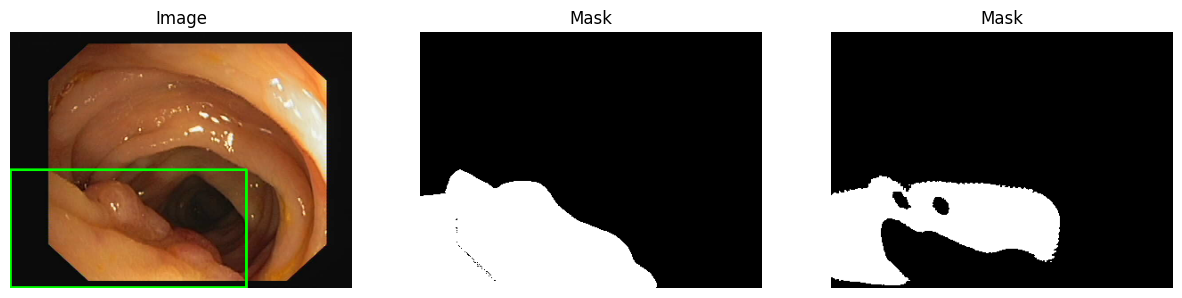

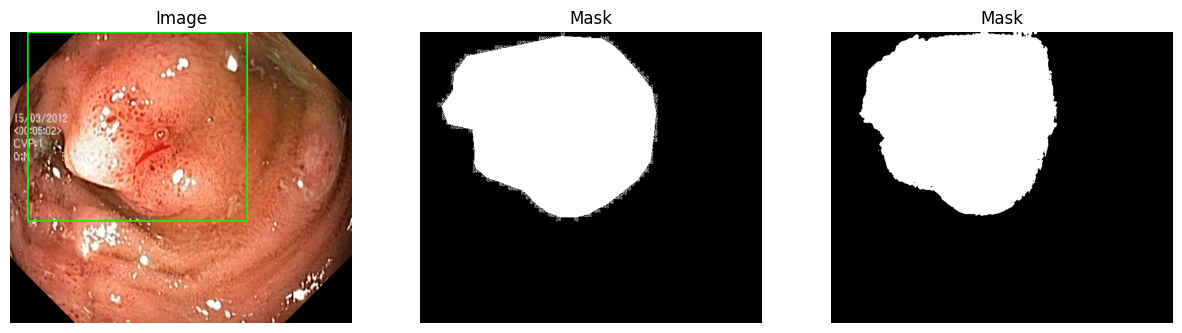

In [23]:
visualize_pred(image, mask, pred_masks[0])
visualize_pred(kva_img, kva_mask, pred_kva_masks[0])

In [24]:
image, mask = cvc_dataset[0]

gt_mask = ensure_2d_mask(mask)
image_rgb = preprocess_rgb(image)
box = mask_to_box(gt_mask)
point = mask_to_point(gt_mask)

med_predictor.set_image(image_rgb)

pred_masks, _, _ = med_predictor.predict(
    box=box,
    point_coords=point,
    point_labels=np.array([1]),
    multimask_output=False
)

kva_img, kva_mask = kva_dataset[0]

gt_kva_mask = ensure_2d_mask(kva_mask)
kva_image_rgb = preprocess_rgb(kva_img)
kva_box = mask_to_box(gt_kva_mask)
kva_point = mask_to_point(gt_kva_mask)

med_predictor.set_image(kva_image_rgb)

pred_kva_masks, _, _ = med_predictor.predict(
    box=kva_box,
    point_coords=kva_point,
    point_labels=np.array([1]),
    multimask_output=False
)

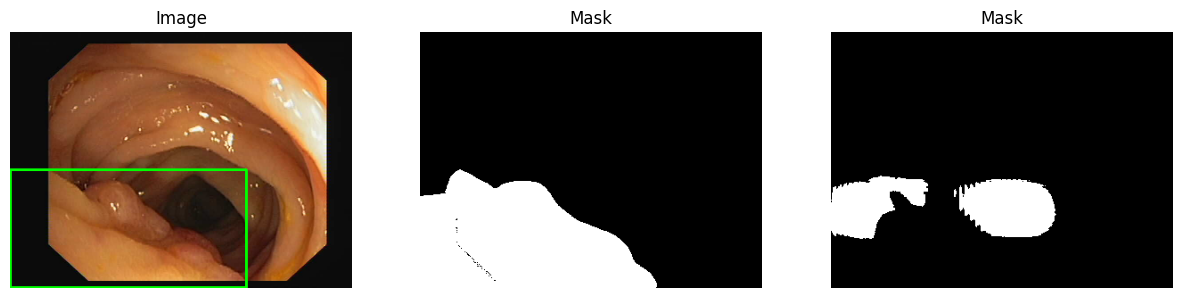

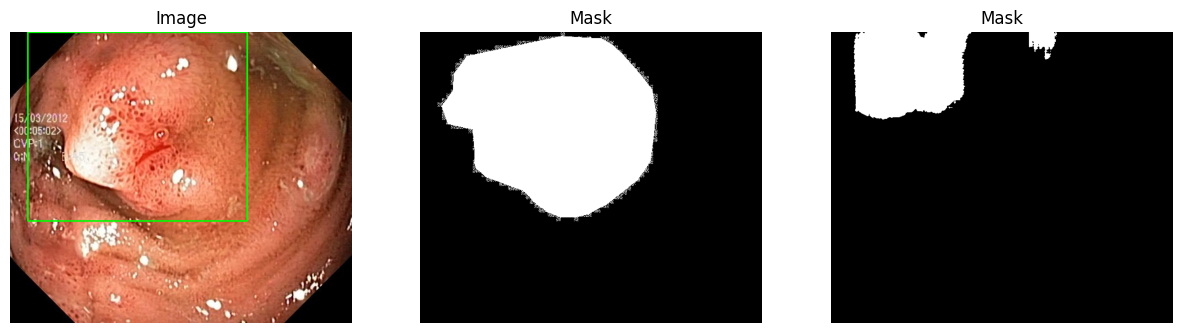

In [25]:
visualize_pred(image, mask, pred_masks[0])
visualize_pred(kva_img, kva_mask, pred_kva_masks[0])

In [26]:
# import cv2

# img_vis = image_rgb.copy()
# x1, y1, x2, y2 = box[0].astype(int)

# cv2.rectangle(img_vis, (x1,y1), (x2,y2), (0,255,0), 2)
# plt.imshow(img_vis)
# plt.axis("off")

In [27]:
class EvaluationCutout:
    def __init__(
        self,
        coverage_levels=(0.1, 0.3, 0.5),
        shapes=("circle", "rect"),
        location="inside",          # inside | boundary
        fill_value=0,
        seed=None,
        max_size=200,
    ):
        self.coverage_levels = list(coverage_levels)
        self.shapes = list(shapes)
        self.location = location
        self.fill_value = fill_value
        self.max_size = max_size
        self.rng = np.random.RandomState(seed)

    # -----------------------------
    def _sample_center(self, mask):
        if self.location == "inside":
            ys, xs = np.where(mask > 0)
        else:
            edge = cv2.morphologyEx(
                mask, cv2.MORPH_GRADIENT, np.ones((3, 3), np.uint8)
            )
            ys, xs = np.where(edge > 0)

        if len(xs) == 0:
            return None
        i = self.rng.randint(len(xs))
        return xs[i], ys[i]

    # -----------------------------
    def _make_blob(self, cx, cy, size, shape, h, w):
        blob = np.zeros((h, w), np.uint8)

        if shape == "circle":
            cv2.circle(blob, (cx, cy), size, 1, -1)
        else:
            rw, rh = size
            x1, x2 = max(0, cx - rw), min(w, cx + rw)
            y1, y2 = max(0, cy - rh), min(h, cy + rh)
            blob[y1:y2, x1:x2] = 1

        return blob

    # -----------------------------
    def __call__(self, image, mask, prompt_point=None, return_stats=False):
        is_tensor = torch.is_tensor(image)

        img = (
            image.permute(1,2,0).cpu().numpy().copy()
            if is_tensor else image.copy()
        )
        mask_np = (
            mask.squeeze(0).cpu().numpy().copy()
            if torch.is_tensor(mask) else mask.copy()
        )

        mask_bin = (mask_np > 0).astype(np.uint8)
        obj_area = mask_bin.sum()
        if obj_area == 0:
            return image

        h, w = mask_bin.shape

        target_cov = float(self.rng.choice(self.coverage_levels))
        target_area = target_cov * obj_area
        shape = self.rng.choice(self.shapes)

        center = self._sample_center(mask_bin)
        if center is None:
            return image
        cx, cy = center

        blob = None
        occluded = 0
        avoid_prompt = target_cov <= 0.3

        for s in range(5, self.max_size, 2):
            if shape == "circle":
                size = s
            else:
                aspect = self.rng.uniform(0.5, 2.0)
                size = (int(s * aspect), int(s / aspect))

            cand = self._make_blob(cx, cy, size, shape, h, w)

            # # ---- ensure fully inside object ----
            # if self.location == "inside":
            #     if (cand & (~mask_bin)).any():
            #         continue

            if avoid_prompt and prompt_point is not None:
                # px, py = prompt_point
                px, py = map(int, prompt_point[0])
                if cand[py, px]:
                    continue

            occluded = (cand & mask_bin).sum()
            if occluded >= target_area:
                blob = cand.astype(bool)
                break

        if blob is None:
            return image

        img[blob] = self.fill_value

        if is_tensor:
            img = torch.from_numpy(img).permute(2,0,1).float()

        if return_stats:
            return img, {
                "blob": blob,
                "target_cov": target_cov,
                "actual_cov": occluded / obj_area,
                "shape": shape,
                "location": self.location,
            }

        return img

In [28]:
# class EvaluationCutout:
#     """
#     Research-grade cutout with:
#     - hard inside-mask constraint
#     - soft coverage constraint
#     - soft prompt-avoidance
#     - adaptive blob size
#     - never fails
#     """

#     def __init__(
#         self,
#         coverage_levels=(0.1, 0.3, 0.5),
#         shapes=("circle", "rect"),
#         location="inside",
#         fill_value=0,
#         seed=None,
#     ):
#         self.coverage_levels = list(coverage_levels)
#         self.shapes = list(shapes)
#         self.location = location
#         self.fill_value = fill_value
#         self.rng = np.random.RandomState(seed)

#     def _sample_center(self, mask):
#         if self.location == "inside":
#             ys, xs = np.where(mask > 0)
#         else:
#             edge = cv2.morphologyEx(
#                 mask, cv2.MORPH_GRADIENT, np.ones((3, 3), np.uint8)
#             )
#             ys, xs = np.where(edge > 0)

#         if len(xs) == 0:
#             return None
#         i = self.rng.randint(len(xs))
#         return xs[i], ys[i]

#     def _make_blob(self, cx, cy, size, shape, h, w):
#         blob = np.zeros((h, w), np.uint8)
#         if shape == "circle":
#             cv2.circle(blob, (cx, cy), size, 1, -1)
#         else:
#             rw, rh = size
#             blob[
#                 max(0, cy - rh):min(h, cy + rh),
#                 max(0, cx - rw):min(w, cx + rw),
#             ] = 1
#         return blob

#     def __call__(self, image, mask, prompt_point=None, return_stats=False):
#         is_tensor = torch.is_tensor(image)

#         img = (
#             image.clone().permute(1, 2, 0).cpu().numpy()
#             if is_tensor else image.copy()
#         )
#         mask_np = (
#             mask.squeeze(0).cpu().numpy()
#             if torch.is_tensor(mask) else mask.copy()
#         )

#         mask_bin = (mask_np > 0).astype(np.uint8)
#         obj_area = mask_bin.sum()
#         if obj_area == 0:
#             return (image, None) if return_stats else image

#         h, w = mask_bin.shape

#         target_cov = float(self.rng.choice(self.coverage_levels))
#         target_area = target_cov * obj_area
#         avoid_prompt = target_cov <= 0.3
#         shape = self.rng.choice(self.shapes)

#         center = self._sample_center(mask_bin)
#         if center is None:
#             return (image, None) if return_stats else image
#         cx, cy = center

#         ys, xs = np.where(mask_bin)
#         bbox_h = ys.max() - ys.min() + 1
#         bbox_w = xs.max() - xs.min() + 1
#         max_size = max(5, min(int(0.5 * min(bbox_h, bbox_w)),
#                                int(2 * np.sqrt(target_area))))

#         best_blob = None
#         best_occluded = 0
#         best_hit_prompt = True

#         for s in range(3, max_size + 1, 2):
#             size = s if shape == "circle" else (
#                 int(s * self.rng.uniform(0.5, 2.0)),
#                 int(s / self.rng.uniform(0.5, 2.0))
#             )

#             cand = self._make_blob(cx, cy, size, shape, h, w)

#             if self.location == "inside" and (cand & (~mask_bin)).any():
#                 continue

#             occluded = (cand & mask_bin).sum()
#             if occluded == 0:
#                 continue

#             hit_prompt = False
#             if prompt_point is not None:
#                 px, py = map(int, prompt_point[0])
#                 px = np.clip(px, 0, w - 1)
#                 py = np.clip(py, 0, h - 1)
#                 hit_prompt = cand[py, px] == 1

#             if avoid_prompt and hit_prompt:
#                 continue

#             if occluded > best_occluded or (
#                 occluded == best_occluded and not hit_prompt
#             ):
#                 best_blob = cand
#                 best_occluded = occluded
#                 best_hit_prompt = hit_prompt

#             if occluded >= target_area:
#                 break

#         if best_blob is None:
#             return (image, None) if return_stats else image

#         img[best_blob.astype(bool)] = self.fill_value

#         if is_tensor:
#             img = torch.from_numpy(img).permute(2, 0, 1).float()

#         if return_stats:
#             return img, {
#                 "target_cov": target_cov,
#                 "actual_cov": best_occluded / obj_area,
#                 "shape": shape,
#                 "hit_prompt": best_hit_prompt,
#                 "success": best_occluded >= target_area,
#             }

#         return img

In [29]:
class EvaluationCutMix(EvaluationCutout):
    def __init__(self, dataset, mix_mode="background", **kwargs):
        super().__init__(**kwargs)
        assert mix_mode in ["background", "foreground", "random"]
        self.dataset = dataset
        self.mix_mode = mix_mode

    # -----------------------------
    def _sample_other(self, cur_idx, target_shape):
        idx = self.rng.randint(len(self.dataset))
        while idx == cur_idx:
            idx = self.rng.randint(len(self.dataset))

        img, mask = self.dataset[idx]

        if torch.is_tensor(img):
            img = img.permute(1,2,0).cpu().numpy().copy()
            mask = mask.squeeze(0).cpu().numpy().copy()

        # ---- resize to target shape ----
        h, w = target_shape
        img = cv2.resize(img, (w, h), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

        return img, (mask > 0).astype(np.uint8)

    # -----------------------------
    def _extract_patch(self, src_img, src_mask, blob):
        patch = np.zeros_like(src_img)

        if self.mix_mode == "random":
            patch[blob] = src_img[blob]

        elif self.mix_mode == "background":
            valid = blob & (src_mask == 0)
            if valid.sum() == 0:
                return None
            patch[valid] = src_img[valid]

        else:  # foreground
            valid = blob & (src_mask == 1)
            if valid.sum() == 0:
                return None
            patch[valid] = src_img[valid]

        return patch

    # -----------------------------
    def __call__(
        self,
        image,
        mask,
        cur_idx,
        prompt_point=None,
        return_stats=False,
    ):
        # 1. Cutout → lấy blob
        img_cut, stats = super().__call__(
            image,
            mask,
            prompt_point=prompt_point,
            return_stats=True,
        )

        blob = stats["blob"]
        if blob is None:
            return image

        # 2. Lấy source image
        H, W = blob.shape
        src_img, src_mask = self._sample_other(cur_idx, (H, W))
        patch = self._extract_patch(src_img, src_mask, blob)

        if patch is None:
            return image if not return_stats else (image, stats)

        # 3. Apply CutMix
        is_tensor = torch.is_tensor(image)
        img_np = (
            image.permute(1,2,0).cpu().numpy().copy()
            if is_tensor else image.copy()
        )

        img_np[blob] = patch[blob]

        if is_tensor:
            img_np = torch.from_numpy(img_np).permute(2,0,1).float()

        if return_stats:
            return img_np, stats

        return img_np

In [30]:
def visualize_cut(image, mask, img_cut):
    image = image.permute(1, 2, 0).cpu().numpy()
    mask = mask.squeeze(0).cpu().numpy()
    
    img = draw_box(image, mask)
    img_occ = draw_box(img_cut, mask)
    
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    
    plt.subplot(1,3,2)
    if torch.is_tensor(mask):
        plt.imshow(mask.squeeze(0).cpu().numpy(), cmap="gray")
    else:
        plt.imshow(mask, cmap="gray")
    plt.title("Mask")
    plt.axis("off")
    
    plt.subplot(1,3,3)
    plt.imshow(img_occ)
    plt.title("Image Occ")
    
    plt.show()

In [31]:
image, mask = cvc_dataset[0]
kva_img, kva_mask = kva_dataset[0]

point = mask_to_point(mask)
kva_point = mask_to_point(gt_kva_mask)

print(point)
print(kva_point)

cutout = EvaluationCutout(
    coverage_levels=[0.5],
    shapes=["rect"],
    location="boundary",
    seed=42,
)

img_occ, stats = cutout(
    image,
    mask,
    prompt_point=(point),  # positive point của SAM
    return_stats=True
)

kva_img_occ, stats = cutout(
    kva_img,
    kva_mask,
    prompt_point=(kva_point),  # positive point của SAM
    return_stats=True
)

[[107.9637  235.58867]]
[[248.40994 160.89261]]


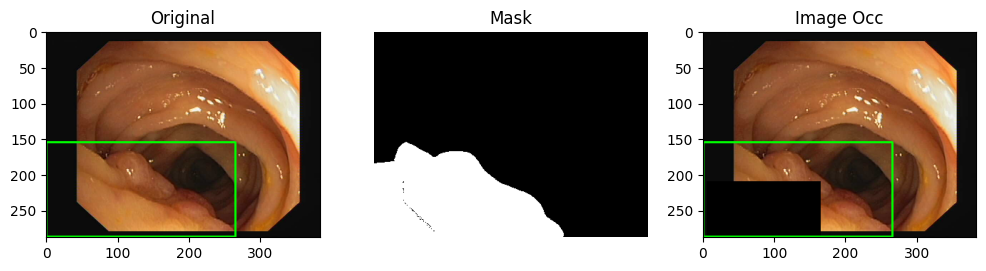

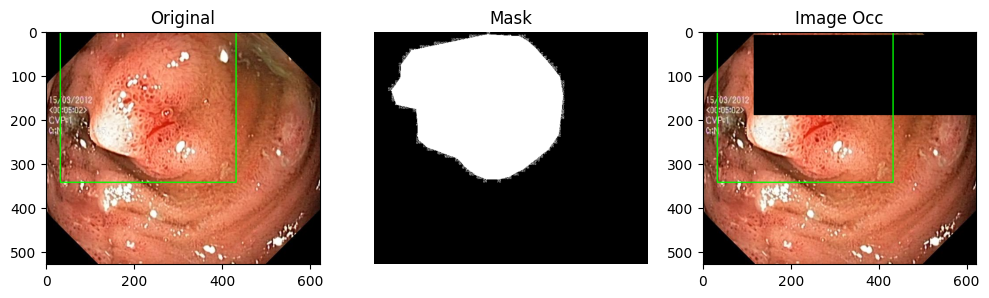

In [32]:
visualize_cut(image, mask, img_occ)
visualize_cut(kva_img, kva_mask, kva_img_occ)

In [33]:
gt_mask = ensure_2d_mask(mask)
image_rgb = preprocess_rgb(img_occ)
box = mask_to_box(gt_mask)
point = mask_to_point(gt_mask)

predictor.set_image(image_rgb)

pred_masks, _, _ = predictor.predict(
    box=box,
    point_coords=point,
    point_labels=np.array([1]),
    multimask_output=False
)

In [34]:
gt_kva_mask = ensure_2d_mask(kva_mask)
kva_image_rgb = preprocess_rgb(kva_img_occ)
kva_box = mask_to_box(gt_mask)
kva_point = mask_to_point(kva_mask)

predictor.set_image(kva_image_rgb)

kva_pred_masks, _, _ = predictor.predict(
    box=kva_box,
    point_coords=point,
    point_labels=np.array([1]),
    multimask_output=False
)

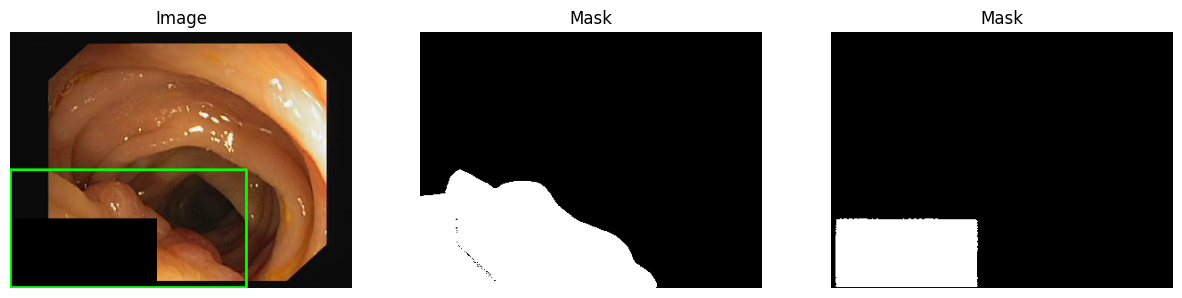

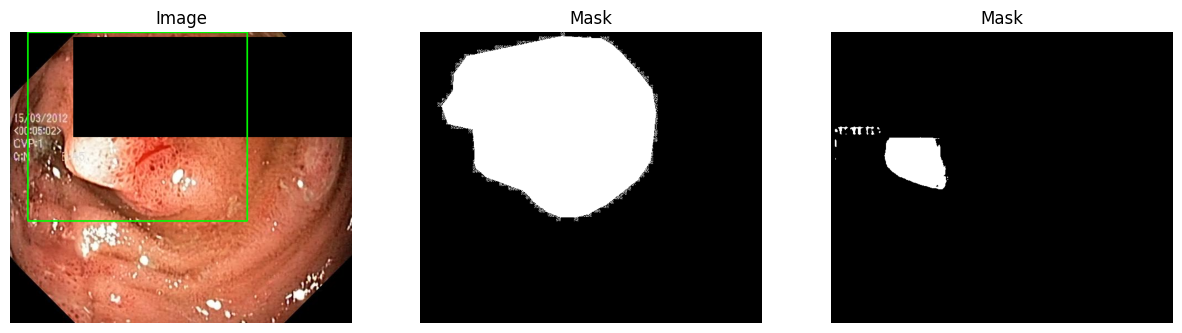

In [35]:
visualize_pred(img_occ, mask, pred_masks[0])
visualize_pred(kva_img_occ, kva_mask, kva_pred_masks[0])

In [36]:
image, mask = cvc_dataset[0]
kva_img, kva_mask = kva_dataset[0]

cutmix = EvaluationCutMix(
    dataset=cvc_dataset,
    coverage_levels=[0.5],
    shapes=["rect"],
    location="boundary",
    mix_mode="background",   # hoặc "foreground", "random"
    seed=42,
)

kva_cutmix = EvaluationCutMix(
    dataset=kva_dataset,
    coverage_levels=[0.5],
    shapes=["rect"],
    location="boundary",
    mix_mode="background",   # hoặc "foreground", "random"
    seed=42,
)

img_mix, stats_cutmix = cutmix(
    image,
    mask,
    cur_idx=0,
    prompt_point=point,
    return_stats=True
)

kva_img_mix, stats_cutmix = kva_cutmix(
    kva_img,
    kva_mask,
    cur_idx=0,
    prompt_point=point,
    return_stats=True
)

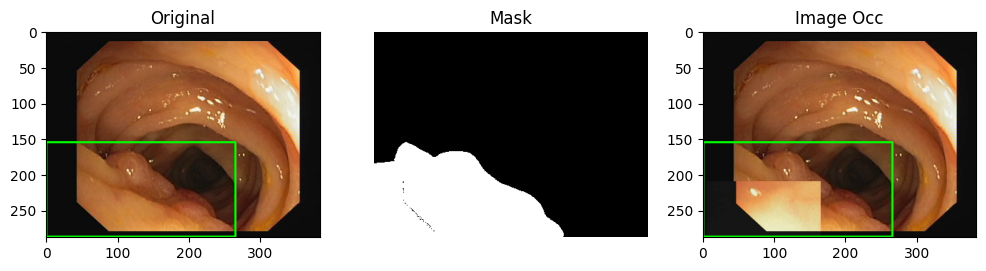

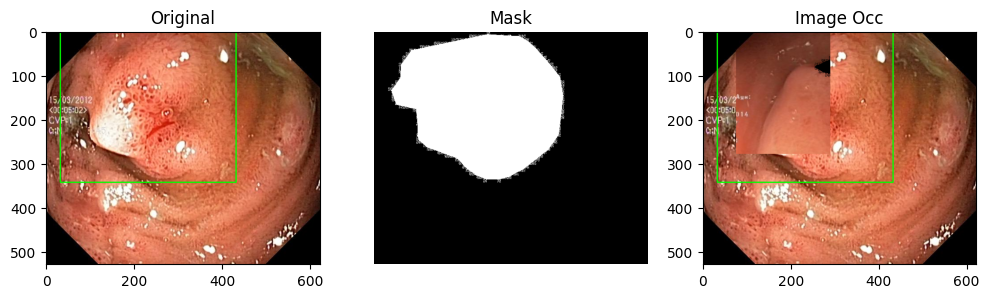

In [37]:
visualize_cut(image, mask, img_mix)
visualize_cut(kva_img, kva_mask, kva_img_mix)

In [38]:
def infer_image_sam(image_rgb, gt_mask, predictor, use_point=True):
    gt_mask = ensure_2d_mask(gt_mask)
    image_rgb = preprocess_rgb(image_rgb)

    box = mask_to_box(gt_mask)
    if box is None:
        return np.zeros_like(gt_mask)
        
    point = mask_to_point(gt_mask)
    
    predictor.set_image(image_rgb)

    if use_point:
        pred_masks, _, _ = predictor.predict(
            box=box,
            point_coords=point,
            point_labels=np.array([1]),
            multimask_output=False
        )
    else:
        pred_masks, _, _ = predictor.predict(
            box=box,
            point_coords=None,
            point_labels=None,
            multimask_output=False
        )

    return pred_masks[0].astype(np.uint8)

In [39]:
pred_mask = infer_image_sam(img_mix, mask, predictor, True)
kva_pred_mask = infer_image_sam(kva_img_mix, kva_mask, predictor, True)

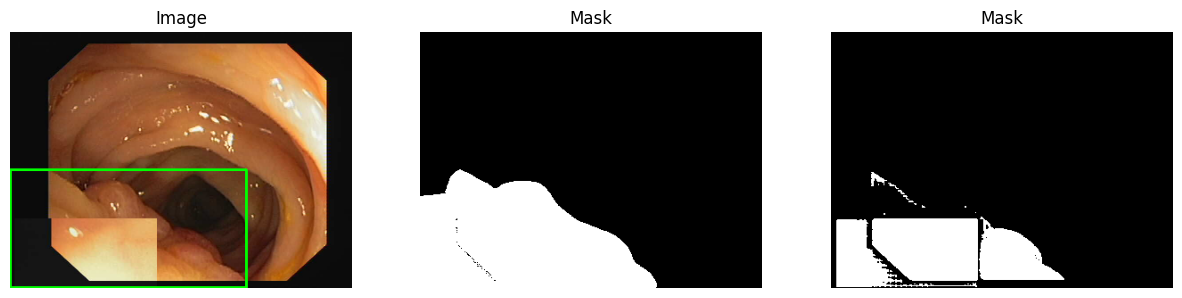

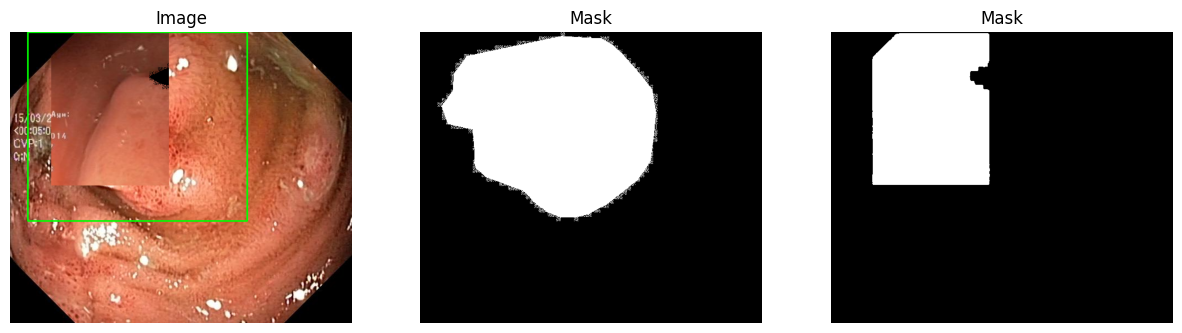

In [40]:
visualize_pred(img_mix, mask, pred_mask)
visualize_pred(kva_img_mix, kva_mask, kva_pred_mask)

In [41]:
pred_mask_med = infer_image_sam(img_mix, mask, med_predictor, False)
kva_pred_mask_med = infer_image_sam(kva_img_mix, kva_mask, med_predictor, False)

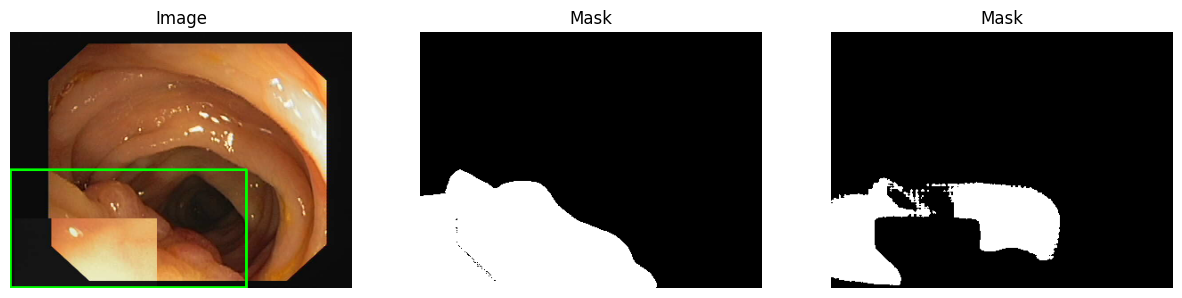

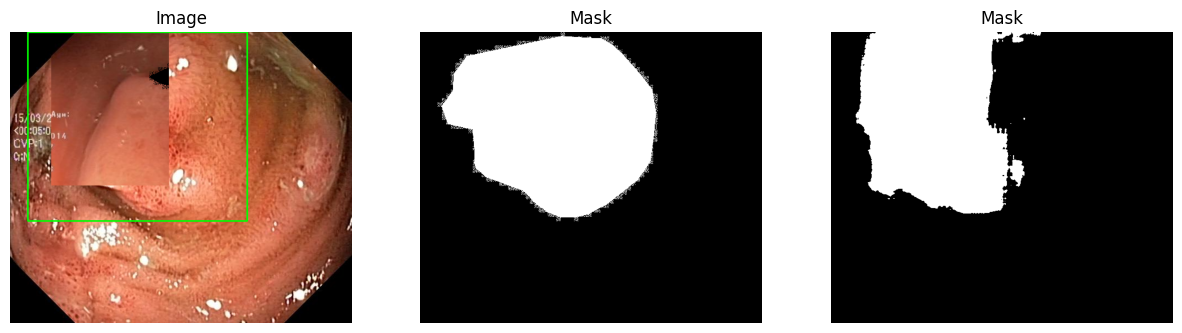

In [42]:
visualize_pred(img_mix, mask, pred_mask_med)
visualize_pred(kva_img_mix, kva_mask, kva_pred_mask_med)

In [43]:
def extract_tool_patch(image, tool_mask, min_area=300):
    """
    image: (3,H,W) torch | (H,W,3) np
    tool_mask: (1,H,W) torch | (H,W) np
    return: tool_img, tool_mask or (None, None)
    """

    if torch.is_tensor(image):
        image = image.permute(1,2,0).cpu().numpy()

    if torch.is_tensor(tool_mask):
        tool_mask = tool_mask.squeeze(0).cpu().numpy()

    tool_mask = (tool_mask > 0).astype(np.uint8)
    ys, xs = np.where(tool_mask)

    if len(xs) == 0:
        return None, None

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    area = tool_mask[y1:y2+1, x1:x2+1].sum()
    if area < min_area:
        return None, None

    return (
        image[y1:y2+1, x1:x2+1],
        tool_mask[y1:y2+1, x1:x2+1]
    )

In [44]:
def transform_tool(
    tool_img,
    tool_mask,
    scale_range=(0.5, 1.2),
    rotation_range=(-45, 45),
    rng=None
):
    rng = np.random.RandomState() if rng is None else rng

    # ---- scale ----
    scale = rng.uniform(*scale_range)
    h, w = tool_mask.shape
    nh, nw = int(h * scale), int(w * scale)

    tool_img = cv2.resize(tool_img, (nw, nh))
    tool_mask = cv2.resize(
        tool_mask, (nw, nh),
        interpolation=cv2.INTER_NEAREST
    )

    # ---- rotation ----
    angle = rng.uniform(*rotation_range)
    center = (nw // 2, nh // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    tool_img = cv2.warpAffine(
        tool_img, M, (nw, nh),
        flags=cv2.INTER_LINEAR,
        borderValue=0
    )

    tool_mask = cv2.warpAffine(
        tool_mask, M, (nw, nh),
        flags=cv2.INTER_NEAREST,
        borderValue=0
    )

    return tool_img, tool_mask

In [45]:
def paste_tool(
    target_img,
    target_mask,
    tool_img,
    tool_mask,
    location="inside",     # inside | boundary | random
    seed=None
):
    rng = np.random.RandomState(seed)

    is_tensor = torch.is_tensor(target_img)
    if is_tensor:
        target_img_np = (target_img.clone().permute(1, 2, 0).cpu().numpy().copy())
    else:
        target_img_np = target_img.copy()

    if torch.is_tensor(target_mask):
        target_mask = target_mask.squeeze(0).cpu().numpy()

    H, W = target_mask.shape
    mask_bin = (target_mask > 0).astype(np.uint8)

    # ---- sample paste center ----
    if location == "inside":
        ys, xs = np.where(mask_bin > 0)

    elif location == "boundary":
        edge = cv2.morphologyEx(
            mask_bin, cv2.MORPH_GRADIENT, np.ones((3,3))
        )
        ys, xs = np.where(edge > 0)

    else:  # random
        ys = rng.randint(0, H, size=1000)
        xs = rng.randint(0, W, size=1000)

    if len(xs) == 0:
        return target_img_np

    i = rng.randint(len(xs))
    cx, cy = xs[i], ys[i]

    # ---- paste region ----
    th, tw = tool_mask.shape
    x1 = max(0, cx - tw // 2)
    y1 = max(0, cy - th // 2)
    x2 = min(W, x1 + tw)
    y2 = min(H, y1 + th)

    roi = target_img_np[y1:y2, x1:x2]
    tool_crop = tool_img[:y2-y1, :x2-x1]
    mask_crop = tool_mask[:y2-y1, :x2-x1].astype(bool)

    roi[mask_crop] = tool_crop[mask_crop]
    target_img_np[y1:y2, x1:x2] = roi

    if is_tensor:
        return torch.from_numpy(target_img_np).permute(2, 0, 1).float()

    return target_img_np

In [46]:
# ---- load tool ----
tool_img, tool_mask = tool_dataset[0]

tool_patch, tool_patch_mask = extract_tool_patch(
    tool_img, tool_mask
)

# ---- transform ----
rng = np.random.RandomState(42)
tool_t, tool_m = transform_tool(
    tool_patch,
    tool_patch_mask,
    scale_range=(1.0, 1.0),
    rotation_range=(-0, 0),
    rng=rng
)

# ---- target ----
image, mask = cvc_dataset[0]
kva_img, kva_mask = kva_dataset[0]

img_occ = paste_tool(
    image,
    mask,
    tool_t,
    tool_m,
    location="inside",
    seed=42
)

kva_img_occ = paste_tool(
    kva_img,
    kva_mask,
    tool_t,
    tool_m,
    location="inside",
    seed=42
)

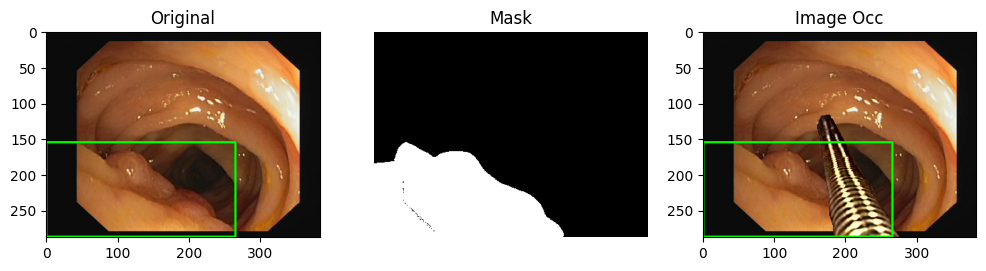

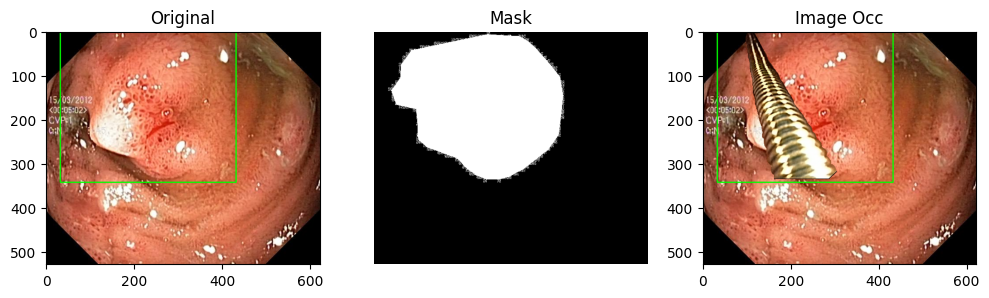

In [47]:
visualize_cut(image, mask, img_occ)
visualize_cut(kva_img, kva_mask, kva_img_occ)

In [48]:
pred_mask = infer_image_sam(img_occ, mask, predictor, True)
kva_pred_mask = infer_image_sam(kva_img_occ, kva_mask, predictor, True)

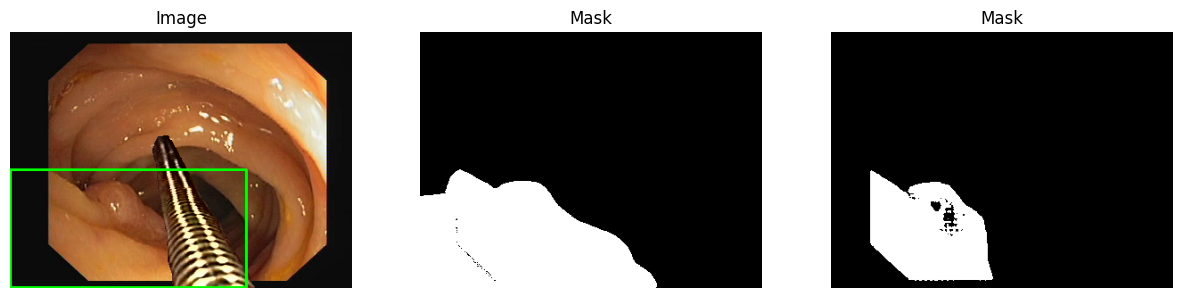

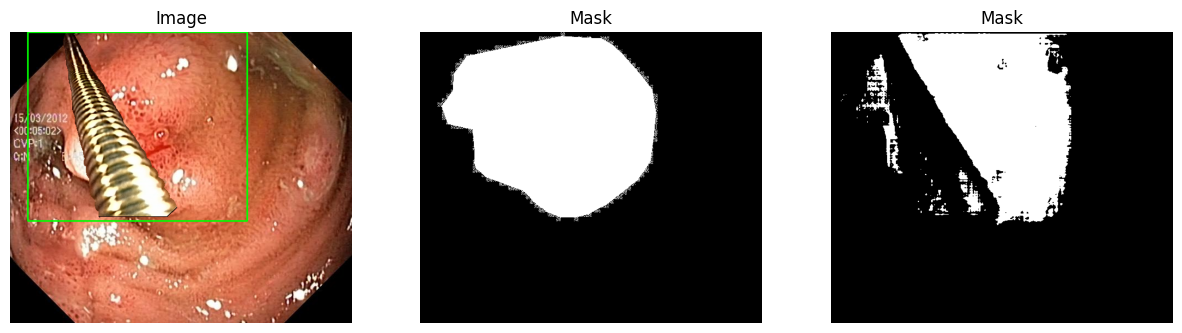

In [49]:
visualize_pred(img_occ, mask, pred_mask)
visualize_pred(kva_img_occ, kva_mask, kva_pred_mask)

In [50]:
pred_mask_med = infer_image_sam(img_occ, mask, med_predictor, False)
kva_pred_mask_med = infer_image_sam(kva_img_occ, kva_mask, med_predictor, False)

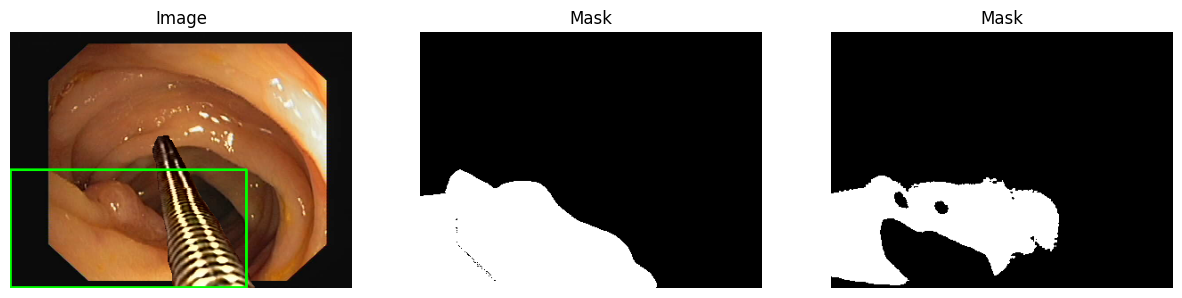

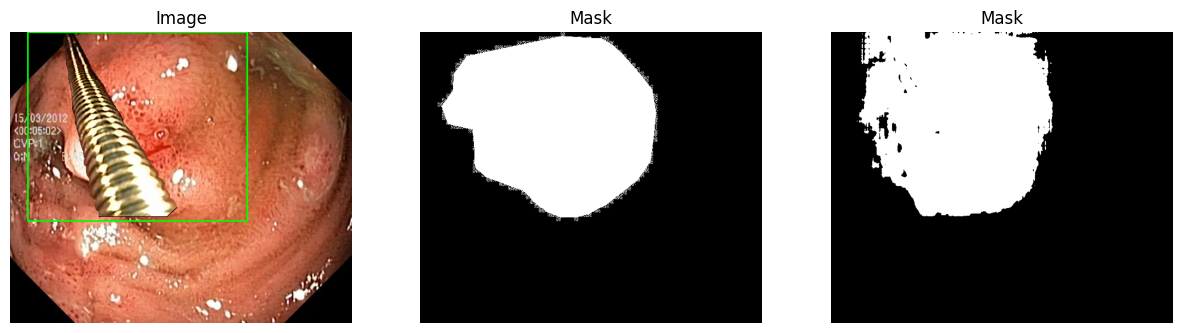

In [51]:
visualize_pred(img_occ, mask, pred_mask_med)
visualize_pred(kva_img_occ, kva_mask, kva_pred_mask_med)

# **Helper functions (preprocess + prompt)**

In [52]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CHECKPOINT_PATH = "/kaggle/working/sam_vit_b_01ec64.pth"

sam = sam_model_registry["vit_b"](
    checkpoint=CHECKPOINT_PATH
).to(DEVICE)

sam.eval()
predictor = SamPredictor(sam)

In [53]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MEDSAM_CHECKPOINT_PATH = "/kaggle/working/medsam_vit_b.pth"

medsam = sam_model_registry['vit_b'](checkpoint=MEDSAM_CHECKPOINT_PATH).to(DEVICE)
medsam.eval()
med_predictor = SamPredictor(medsam)

In [54]:
# def infer_image_sam(image_rgb, gt_mask, predictor, use_point=False):
#     gt_mask = ensure_2d_mask(gt_mask)
#     image_rgb = preprocess_rgb(image_rgb)

#     box = mask_to_box(gt_mask)
#     if box is None:
#         return np.zeros_like(gt_mask)
        
#     point = mask_to_point(gt_mask)
    
#     predictor.set_image(image_rgb)

#     if use_point:
#         pred_masks, _, _ = predictor.predict(
#             box=box,
#             point_coords=point,
#             point_labels=np.array([1]),
#             multimask_output=False
#         )
#     else:
#         pred_masks, _, _ = predictor.predict(
#             box=box,
#             point_coords=None,
#             point_labels=None,
#             multimask_output=False
#         )

#     return pred_masks[0].astype(np.uint8)

In [55]:
def dice_2d(pred, gt, eps=1e-8):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    return 2 * inter / (pred.sum() + gt.sum() + eps)


def iou_2d(pred, gt, eps=1e-8):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return (inter + eps) / (union + eps)

In [56]:
from scipy.spatial.distance import directed_hausdorff
from scipy.ndimage import binary_erosion
from scipy.spatial import cKDTree

def extract_surface(mask):
    eroded = binary_erosion(mask)
    return np.argwhere(mask ^ eroded)

def hausdorff_2d(pred, gt):
    p = np.argwhere(pred > 0)
    g = np.argwhere(gt > 0)
    if len(p) == 0 or len(g) == 0:
        return np.inf
    return max(
        directed_hausdorff(p, g)[0],
        directed_hausdorff(g, p)[0]
    )

def assd_2d(pred, gt):
    p = extract_surface(pred)
    g = extract_surface(gt)
    if len(p) == 0 or len(g) == 0:
        return np.inf
    tp = cKDTree(p)
    tg = cKDTree(g)
    d1, _ = tp.query(g)
    d2, _ = tg.query(p)
    return (d1.mean() + d2.mean()) / 2

In [57]:
def run_single_sample(predictor, img, gt_mask, img_occ, use_point=True):
    # --- ensure numpy ---
    if torch.is_tensor(img):
        img = img.permute(1,2,0).cpu().numpy().copy()

    gt_mask = ensure_2d_mask(gt_mask)

    # ---------- no occ ----------
    pred_normal = infer_image_sam(img, gt_mask, predictor, use_point=use_point)

    # ---------- with occ ----------        
    pred_cut = infer_image_sam(img_occ, gt_mask, predictor, use_point=use_point)
        
    metrics = {
        # overlap
        "normal_dice": dice_2d(pred_normal, gt_mask),
        "occ_dice": dice_2d(pred_cut, gt_mask),
        "normal_iou": iou_2d(pred_normal, gt_mask),
        "occ_iou": iou_2d(pred_cut, gt_mask),

        # boundary
        "normal_hd": hausdorff_2d(pred_normal, gt_mask),
        "occ_hd": hausdorff_2d(pred_cut, gt_mask),
        "normal_assd": assd_2d(pred_normal, gt_mask),
        "occ_assd": assd_2d(pred_cut, gt_mask),
    }

    return pred_normal, pred_cut, metrics

In [58]:
# ---- load tool ----
tool_img, tool_mask = tool_dataset[0]

tool_patch, tool_patch_mask = extract_tool_patch(
    tool_img, tool_mask
)

# ---- transform ----
rng = np.random.RandomState(42)
tool_t, tool_m = transform_tool(
    tool_patch,
    tool_patch_mask,
    scale_range=(0.5, 0.5),
    rotation_range=(-0, 0),
    rng=rng
)

# ---- target ----
image, mask = cvc_dataset[0]
kva_img, kva_mask = kva_dataset[0]

img_occ = paste_tool(
    image,
    mask,
    tool_t,
    tool_m,
    location="inside",
    seed=42
)

kva_img_occ = paste_tool(
    kva_img,
    kva_mask,
    tool_t,
    tool_m,
    location="inside",
    seed=42
)

{'normal_dice': np.float64(0.7012645313714658), 'occ_dice': np.float64(0.6913566887594506), 'normal_iou': np.float64(0.5399594823667507), 'occ_iou': np.float64(0.5283003266219339), 'normal_hd': 65.76473218982953, 'occ_hd': 65.76473218982953, 'normal_assd': np.float64(13.647671489661438), 'occ_assd': np.float64(14.42853147517699)}
{'normal_dice': np.float64(0.934563351972534), 'occ_dice': np.float64(0.1710294004759182), 'normal_iou': np.float64(0.8771646382756537), 'occ_iou': np.float64(0.09351129018728559), 'normal_hd': 49.4064773081425, 'occ_hd': 103.31021246711285, 'normal_assd': np.float64(11.426869168016353), 'occ_assd': np.float64(45.698342744386835)}


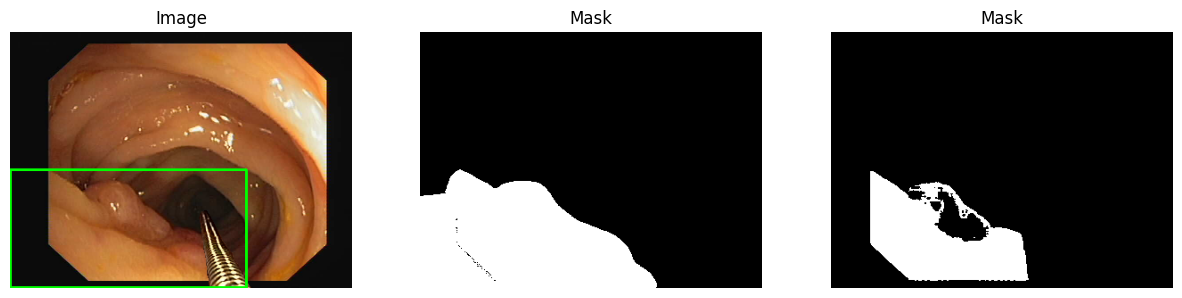

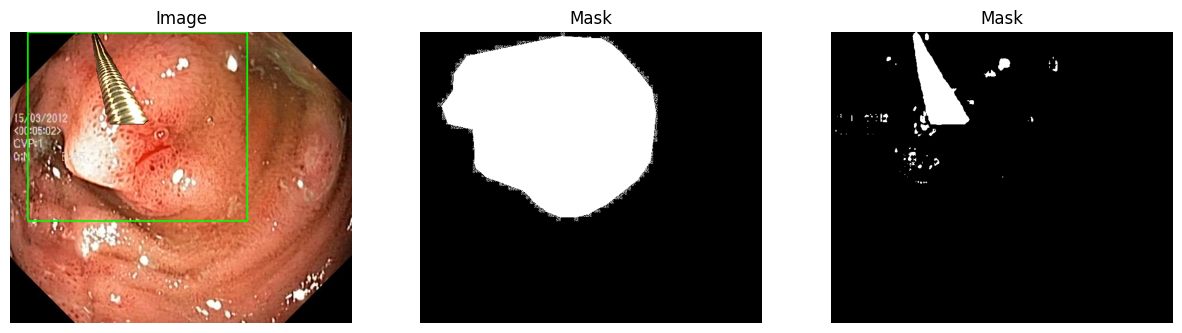

In [59]:
pred_normal, pred_cut, metrics = run_single_sample(predictor, image, mask, img_occ)
kva_pred_normal, kva_pred_cut, kva_metrics = run_single_sample(predictor, kva_img, kva_mask, kva_img_occ)

print(metrics)
print(kva_metrics)

visualize_pred(img_occ, mask, pred_cut)
visualize_pred(kva_img_occ, kva_mask, kva_pred_cut)

{'normal_dice': np.float64(0.6261084663491492), 'occ_dice': np.float64(0.619998112495135), 'normal_iou': np.float64(0.45571899310410174), 'occ_iou': np.float64(0.4492733800651567), 'normal_hd': 49.64876634922564, 'occ_hd': 51.62363799656123, 'normal_assd': np.float64(15.028429273862681), 'occ_assd': np.float64(15.268711886852465)}
{'normal_dice': np.float64(0.9365369520101863), 'occ_dice': np.float64(0.9307152197544898), 'normal_iou': np.float64(0.8806483250927816), 'occ_iou': np.float64(0.8704091154658543), 'normal_hd': 35.84689665786984, 'occ_hd': 33.0, 'normal_assd': np.float64(9.48538629443659), 'occ_assd': np.float64(11.929797271938337)}


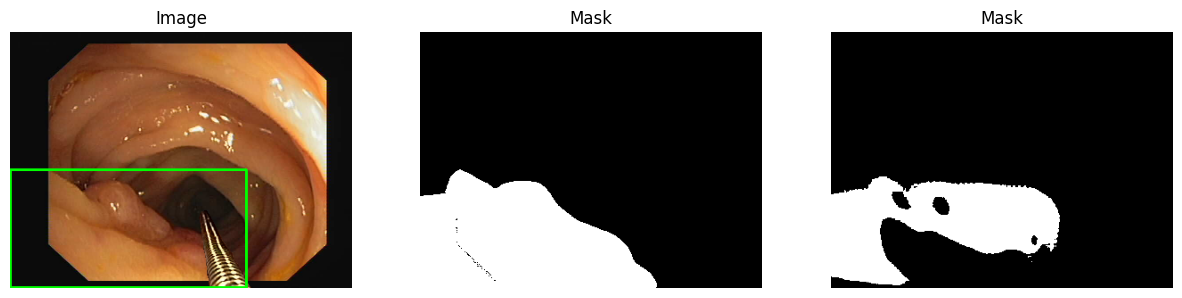

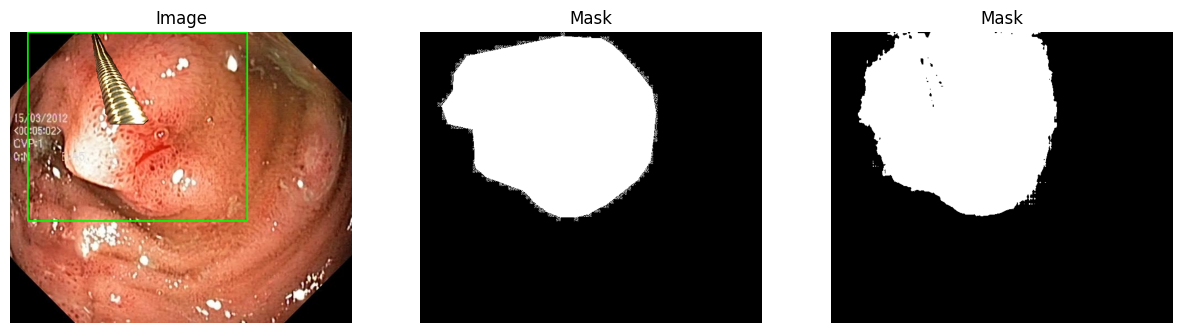

In [60]:
pred_normal_med, pred_cut_med, metrics_med = run_single_sample(med_predictor, image, mask, img_occ, False)
kva_pred_normal_med, kva_pred_cut_med, kva_metrics_med = run_single_sample(med_predictor, kva_img, kva_mask, kva_img_occ, False)

print(metrics_med)
print(kva_metrics_med)

visualize_pred(img_occ, mask, pred_cut_med)
visualize_pred(kva_img_occ, kva_mask, kva_pred_cut_med)

In [61]:
def evaluate_dataset(
    predictor,
    dataset,
    tool_dataset=None, 
    csv_path="sam_occlusion_metrics.csv",
    is_cutout=False,
    is_cutmix=False,
    is_tool=False,
    ratio=0.1,
    scale_range=(1.0, 1.0),
    rotation_range=(-0, 0),
    max_samples=None,   # None = chạy hết dataset
    use_point=True
):
    records = []

    if is_cutout:
        cutout = EvaluationCutout(
            coverage_levels=[ratio],
            shapes=["rect"],
            location="boundary",
            seed=42,
        )
        print("cutout")

    if is_cutmix:
        cutmix = EvaluationCutMix(
            dataset=dataset,
            coverage_levels=[ratio],
            shapes=["rect"],
            location="boundary",
            mix_mode="background",   # hoặc "foreground", "random"
            seed=42,
        )
        print("cutmix")
        

    if is_tool:
        tool_img, tool_mask = tool_dataset[0]

        tool_patch, tool_patch_mask = extract_tool_patch(
            tool_img, tool_mask
        )
        
        rng = np.random.RandomState(42)
        tool_t, tool_m = transform_tool(
            tool_patch,
            tool_patch_mask,
            scale_range=scale_range,
            rotation_range=rotation_range,
            rng=rng
        )
        print("tool")
        
        
    for idx, (image, mask) in enumerate(tqdm(dataset, desc="Evaluating")):
        if max_samples is not None and idx >= max_samples:
            break
            
        try:
            if is_cutout:
                point = mask_to_point(mask)
                img_occ = cutout(
                    image,
                    mask,
                    prompt_point=point,  # positive point của SAM
                    return_stats=False
                )
                

            if is_cutmix:
                point = mask_to_point(mask)
                img_occ = cutmix(
                    image,
                    mask,
                    cur_idx=0,
                    prompt_point=point,
                    return_stats=False
                )
                
                
            if is_tool:
                img_occ = paste_tool(image, mask, tool_t, tool_m, location="inside", seed=42)
                
            _, _, metrics = run_single_sample(predictor, image, mask, img_occ, use_point)
            
            record = {
                "id": idx,
                **metrics
            }

        except Exception as e:
            # phòng trường hợp HD / ASSD lỗi
            record = {
                "id": idx,
                "error": str(e)
            }

        records.append(record)

    df = pd.DataFrame(records)
    df.to_csv(csv_path, index=False)

    print(f"✅ Saved metrics to {csv_path}")
    print(df.describe(include="all"))

    return df

In [62]:
# def evaluate_dataset(
#     predictor,
#     dataset,
#     tool_dataset=None, 
#     csv_path="sam_occlusion_metrics.csv",
#     max_samples=None,   # None = chạy hết dataset
# ):
#     records = []

   
#     tool_img, tool_mask = tool_dataset[0]

#     tool_patch, tool_patch_mask = extract_tool_patch(
#         tool_img, tool_mask
#     )
    
#     rng = np.random.RandomState(42)
#     tool_t, tool_m = transform_tool(
#         tool_patch,
#         tool_patch_mask,
#         scale_range=(1.0, 1.0),
#         rotation_range=(-0, 0),
#         rng=rng
#     )
        
#     for idx, (image, mask) in enumerate(tqdm(dataset, desc="Evaluating")):
#         if max_samples is not None and idx >= max_samples:
#             break
            
#         try:
#             img_occ = paste_tool(image, mask, tool_t, tool_m, location="inside", seed=42)
#             _, _, metrics = run_single_sample(predictor, image, mask, img_occ)
            
#             record = {
#                 "id": idx,
#                 **metrics
#             }

#         except Exception as e:
#             # phòng trường hợp HD / ASSD lỗi
#             record = {
#                 "id": idx,
#                 "error": str(e)
#             }

#         records.append(record)

#     df = pd.DataFrame(records)
#     df.to_csv(csv_path, index=False)

#     print(f"✅ Saved metrics to {csv_path}")
#     print(df.describe(include="all"))

#     return df

In [63]:
cvc_dataset = PolypSegmentationDataset(
    root_dir="/kaggle/input/cvc-clinicdb/PNG",
    dataset_type="cvc",
)

tool_dataset = PolypSegmentationDataset(
    root_dir="/kaggle/input/kvasir-instrument/kvasir-instrument",
    dataset_type="kvasir-instrument",
)

kva_dataset = PolypSegmentationDataset(
    root_dir="/kaggle/input/kvasir-seg/Kvasir-SEG",
    dataset_type="kvasir-polyp",
)

In [64]:
1/0

ZeroDivisionError: division by zero

In [ ]:
# evaluate_dataset(
#     predictor,
#     kva_dataset,
#     tool_dataset=tool_dataset, 
#     csv_path="debug_metrics.csv",
#     is_cutout=False,
#     is_cutmix=False,
#     is_tool=True,
#     ratio=0.1,
#     scale_range=(0.5, 0.5),
#     rotation_range=(-0, 0),
#     max_samples=1,   # None = chạy hết dataset
# )

# df = pd.read_csv("/kaggle/working/debug_metrics.csv")
# df

##sam
# #cvc
# #0.701265    0.539959  0.679929  0.51507  65.764732  65.764732
# #0.701265    0.539959  0.699973  0.53843  65.764732  65.764732
# #0.701265    0.539959  0.666648  0.499979  65.764732  84.480767
# #kva
# #0.934563    0.877165  0.894944  0.809863  49.406477  65.030762
# #0.934563    0.877165  0.900509  0.819023  49.406477    49.0 
# #0.934563    0.877165  0.736235  0.582573  49.406477  63.63961

In [ ]:
# evaluate_dataset(
#     med_predictor,
#     cvc_dataset,
#     tool_dataset=tool_dataset, 
#     csv_path="debug_metrics.csv",
#     is_cutout=True,
#     is_cutmix=False,
#     is_tool=False,
#     ratio=0.1,
    # scale_range=(1.0, 1.0),
    # rotation_range=(-0, 0),
#     max_samples=1,   # None = chạy hết dataset
#     use_point=False
# )

# df = pd.read_csv("/kaggle/working/debug_metrics.csv")
# df

# #medsam
# #cvc
# #0.626108    0.455719  0.666455  0.499762  49.648766  49.193496
# #0.626108    0.455719  0.637648  0.46805  49.648766  49.648766
# #0.626108    0.455719  0.647176  0.478389  49.648766  50.089919
# #kva
# #0.936537    0.880648  0.913317  0.840463  35.846897  43.185646
# #0.936537    0.880648  0.926081  0.862338  35.846897  40.224371 
# #0.936537    0.880648  0.889803  0.801482  35.846897  44.102154 

In [ ]:
# df = evaluate_dataset(
#     predictor,
#     kva_dataset,
#     tool_dataset,
#     csv_path="debug_metrics.csv",
#     max_samples=1,   
# )

# df = pd.read_csv("/kaggle/working/debug_metrics.csv")
# df

SAM

tool

In [ ]:
evaluate_dataset(
    predictor,
    cvc_dataset,
    tool_dataset=tool_dataset, 
    csv_path="cvc_sam_occlusion05_metrics_tool.csv",
    is_cutout=False,
    is_cutmix=False,
    is_tool=True,
    ratio=0.1,
    scale_range=(0.5, 0.5),
    rotation_range=(-0, 0),
    max_samples=None,   # None = chạy hết dataset
    use_point=True
)

In [ ]:
evaluate_dataset(
    predictor,
    cvc_dataset,
    tool_dataset=tool_dataset, 
    csv_path="cvc_sam_occlusion08_metrics_tool.csv",
    is_cutout=False,
    is_cutmix=False,
    is_tool=True,
    ratio=0.1,
    scale_range=(0.8, 0.8),
    rotation_range=(-0, 0),
    max_samples=None,   # None = chạy hết dataset
    use_point=True
)

In [ ]:
evaluate_dataset(
    predictor,
    cvc_dataset,
    tool_dataset=tool_dataset, 
    csv_path="cvc_sam_occlusion10_metrics_tool.csv",
    is_cutout=False,
    is_cutmix=False,
    is_tool=True,
    ratio=0.1,
    scale_range=(1.0, 1.0),
    rotation_range=(-0, 0),
    max_samples=None,   # None = chạy hết dataset
    use_point=True
)

cutmix

In [ ]:
evaluate_dataset(
    predictor,
    cvc_dataset,
    tool_dataset=tool_dataset, 
    csv_path="cvc_sam_occlusion10_metrics_cutmix.csv",
    is_cutout=False,
    is_cutmix=True,
    is_tool=False,
    ratio=0.1,
    scale_range=(1.0, 1.0),
    rotation_range=(-0, 0),
    max_samples=None,   # None = chạy hết dataset
    use_point=True
)

In [ ]:
evaluate_dataset(
    predictor,
    cvc_dataset,
    tool_dataset=tool_dataset, 
    csv_path="cvc_sam_occlusion30_metrics_cutmix.csv",
    is_cutout=False,
    is_cutmix=True,
    is_tool=False,
    ratio=0.3,
    scale_range=(1.0, 1.0),
    rotation_range=(-0, 0),
    max_samples=None,   # None = chạy hết dataset
    use_point=True
)

In [ ]:
evaluate_dataset(
    predictor,
    cvc_dataset,
    tool_dataset=tool_dataset, 
    csv_path="cvc_sam_occlusion50_metrics_cutmix.csv",
    is_cutout=False,
    is_cutmix=True,
    is_tool=False,
    ratio=0.5,
    scale_range=(1.0, 1.0),
    rotation_range=(-0, 0),
    max_samples=None,   # None = chạy hết dataset
    use_point=True
)

cutout

In [ ]:
evaluate_dataset(
    predictor,
    cvc_dataset,
    tool_dataset=tool_dataset, 
    csv_path="cvc_sam_occlusion10_metrics_cutout.csv",
    is_cutout=True,
    is_cutmix=False,
    is_tool=False,
    ratio=0.1,
    scale_range=(1.0, 1.0),
    rotation_range=(-0, 0),
    max_samples=None,   # None = chạy hết dataset
    use_point=True
)

In [ ]:
evaluate_dataset(
    predictor,
    cvc_dataset,
    tool_dataset=tool_dataset, 
    csv_path="cvc_sam_occlusion30_metrics_cutout.csv",
    is_cutout=True,
    is_cutmix=False,
    is_tool=False,
    ratio=0.3,
    scale_range=(1.0, 1.0),
    rotation_range=(-0, 0),
    max_samples=None,   # None = chạy hết dataset
    use_point=True
)

In [ ]:
evaluate_dataset(
    predictor,
    cvc_dataset,
    tool_dataset=tool_dataset, 
    csv_path="cvc_sam_occlusion50_metrics_cutout.csv",
    is_cutout=True,
    is_cutmix=False,
    is_tool=False,
    ratio=0.5,
    scale_range=(1.0, 1.0),
    rotation_range=(-0, 0),
    max_samples=None,   # None = chạy hết dataset
    use_point=True
)

In [ ]:
1/0

MedSAM

cvc tool

In [ ]:
# evaluate_dataset(
#     med_predictor,
#     cvc_dataset,
#     tool_dataset=tool_dataset, 
#     csv_path="cvc_medsam_occlusion05_metrics_tool.csv",
#     is_cutout=False,
#     is_cutmix=False,
#     is_tool=True,
#     ratio=0.1,
#     scale_range=(0.5, 0.5),
#     rotation_range=(-0, 0),
#     max_samples=None,   # None = chạy hết dataset
#     use_point=False
# )

In [ ]:
df = pd.read_csv("cvc_medsam_occlusion05_metrics_tool.csv")
df

In [ ]:
# evaluate_dataset(
#     med_predictor,
#     cvc_dataset,
#     tool_dataset=tool_dataset, 
#     csv_path="cvc_medsam_occlusion08_metrics_tool.csv",
#     is_cutout=False,
#     is_cutmix=False,
#     is_tool=True,
#     ratio=0.1,
#     scale_range=(0.8, 0.8),
#     rotation_range=(-0, 0),
#     max_samples=None,   # None = chạy hết dataset
#     use_point=False
# )

In [ ]:
# evaluate_dataset(
#     med_predictor,
#     cvc_dataset,
#     tool_dataset=tool_dataset, 
#     csv_path="cvc_medsam_occlusion10_metrics_tool.csv",
#     is_cutout=False,
#     is_cutmix=False,
#     is_tool=True,
#     ratio=0.1,
#     scale_range=(1.0, 1.0),
#     rotation_range=(-0, 0),
#     max_samples=None,   # None = chạy hết dataset
#     use_point=False
# )

cvc cutmix

In [ ]:
# evaluate_dataset(
#     med_predictor,
#     cvc_dataset,
#     tool_dataset=tool_dataset, 
#     csv_path="cvc_medsam_occlusion10_metrics_cutmix.csv",
#     is_cutout=False,
#     is_cutmix=True,
#     is_tool=False,
#     ratio=0.1,
#     scale_range=(1.0, 1.0),
#     rotation_range=(-0, 0),
#     max_samples=None,   # None = chạy hết dataset
#     use_point=False
# )

In [ ]:
# df = pd.read_csv("cvc_medsam_occlusion10_metrics_cutmix.csv")
# df

In [ ]:
# evaluate_dataset(
#     med_predictor,
#     cvc_dataset,
#     tool_dataset=tool_dataset, 
#     csv_path="cvc_medsam_occlusion30_metrics_cutmix.csv",
#     is_cutout=False,
#     is_cutmix=True,
#     is_tool=False,
#     ratio=0.3,
#     scale_range=(1.0, 1.0),
#     rotation_range=(-0, 0),
#     max_samples=None,   # None = chạy hết dataset
#     use_point=False
# )

In [ ]:
# evaluate_dataset(
#     med_predictor,
#     cvc_dataset,
#     tool_dataset=tool_dataset, 
#     csv_path="cvc_medsam_occlusion50_metrics_cutmix.csv",
#     is_cutout=False,
#     is_cutmix=True,
#     is_tool=False,
#     ratio=0.5,
#     scale_range=(1.0, 1.0),
#     rotation_range=(-0, 0),
#     max_samples=None,   # None = chạy hết dataset
#     use_point=False
# )

cvc cutout

In [ ]:
# evaluate_dataset(
#     med_predictor,
#     cvc_dataset,
#     tool_dataset=tool_dataset, 
#     csv_path="cvc_medsam_occlusion10_metrics_cutout.csv",
#     is_cutout=True,
#     is_cutmix=False,
#     is_tool=False,
#     ratio=0.1,
#     scale_range=(1.0, 1.0),
#     rotation_range=(-0, 0),
#     max_samples=None,   # None = chạy hết dataset
#     use_point=False
# )

In [ ]:
# evaluate_dataset(
#     med_predictor,
#     cvc_dataset,
#     tool_dataset=tool_dataset, 
#     csv_path="cvc_medsam_occlusion30_metrics_cutout.csv",
#     is_cutout=True,
#     is_cutmix=False,
#     is_tool=False,
#     ratio=0.3,
#     scale_range=(1.0, 1.0),
#     rotation_range=(-0, 0),
#     max_samples=None,   # None = chạy hết dataset
#     use_point=False
# )

In [ ]:
# evaluate_dataset(
#     med_predictor,
#     cvc_dataset,
#     tool_dataset=tool_dataset, 
#     csv_path="cvc_medsam_occlusion50_metrics_cutout.csv",
#     is_cutout=True,
#     is_cutmix=False,
#     is_tool=False,
#     ratio=0.5,
#     scale_range=(1.0, 1.0),
#     rotation_range=(-0, 0),
#     max_samples=None,   # None = chạy hết dataset
#     use_point=False
# )

In [ ]:
1/0

In [ ]:
def draw_box(img, box, color=(0, 255, 0), thickness=2):
    """
    img: HWC RGB numpy OR torch Tensor (C,H,W)
    box: [x1, y1, x2, y2]
    """
    import torch
    import numpy as np
    import cv2

    if box is None:
        return img

    # --- ensure numpy HWC ---
    if torch.is_tensor(img):
        img = img.detach().cpu().permute(1,2,0).numpy()

    if img.dtype != np.uint8:
        img = (img * 255).clip(0,255).astype(np.uint8)

    x1, y1, x2, y2 = box.astype(int)
    img = img.copy()
    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)

    return img

In [ ]:
def to_uint8(img):
    if img.dtype != np.uint8:
        img = (img * 255).clip(0,255).astype(np.uint8)
    return img
    
# --- ensure numpy HWC ---
def to_numpy_hwc(x):
    if torch.is_tensor(x):
        x = x.detach().cpu().permute(1,2,0).numpy()
    return x
    
def visualize(img, gt, pred1, img_cut, pred2, blob=None):
    img = to_numpy_hwc(img)
    img_cut = to_numpy_hwc(img_cut)

    gt = ensure_2d_mask(gt)

    # --- box from GT ---
    box = mask_to_box(gt)

    # --- draw boxes ---
    img_box = draw_box(img, box)
    img_cut_box = draw_box(img_cut, box)

    plt.figure(figsize=(18,9))

    plt.subplot(2,4,1)
    plt.imshow(to_uint8(img_box))
    plt.title("Original + Box")

    plt.subplot(2,4,2)
    plt.imshow(gt, cmap="gray")
    plt.title("GT Mask")

    plt.subplot(2,4,3)
    plt.imshow(pred1, cmap="gray")
    plt.title("Pred (No Cut)")

    plt.subplot(2,4,5)
    plt.imshow(to_uint8(img_cut_box))
    plt.title("Image + Cut + Box")

    if blob is not None:
        overlay = img_cut.copy()
        overlay[blob == 1] = [255, 0, 0]
        overlay = draw_box(overlay, box)

        plt.subplot(2,4,6)
        plt.imshow(to_uint8(overlay))
        plt.title("Cut Overlay + Box")

    plt.subplot(2,4,7)
    plt.imshow(pred2, cmap="gray")
    plt.title("Pred (Cut)")

    for ax in plt.gcf().axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
image, mask = cvc_dataset[0]

cutout = EvaluationCutout(
    coverage_levels=[0.5],
    shapes=["rect"],
    location="boundary",
    seed=42,
)

# img_occ, stats = cutout(image, mask, prompt_point=(point), return_stats=True)

cutmix = EvaluationCutMix(
    dataset=cvc_dataset,
    coverage_levels=[0.5],
    shapes=["rect"],
    location="boundary",
    mix_mode="background",   # hoặc "foreground", "random"
    seed=42,
)

# img_mix, stats_cutmix = cutmix(image, mask, cur_idx=0, prompt_point=point, return_stats=True)


# ---- load tool ----
tool_img, tool_mask = tool_dataset[0]

tool_patch, tool_patch_mask = extract_tool_patch(
    tool_img, tool_mask
)

# ---- transform ----
rng = np.random.RandomState(42)
tool_t, tool_m = transform_tool(
    tool_patch,
    tool_patch_mask,
    scale_range=(0.6, 1.2),
    rotation_range=(0, 0),
    rng=rng
)

# ---- target ----
# img_occ = paste_tool(image, mask, tool_t, tool_m, location="inside", seed=42)

In [ ]:
image, mask = cvc_dataset[500]

pred_n, pred_c, img_cut, metrics = run_single_sample(predictor, 
                                                           image, 
                                                           mask, 
                                                           cutout=cutout, 
                                                           cutmix=None, 
                                                           tool=None, 
                                                           tool_t=None, 
                                                           tool_m=None
                                                          )

print(metrics)


In [ ]:
# print(f"Target={metrics['target_cov']*100:.0f}% | Actual={metrics['actual_cov']*100:.1f}% | Shape={metrics['shape']} | Loc={metrics['location']}")

# overlay_cut_mask(img_cut, mask, blob, metrics['target_cov'])

In [ ]:
# visualize(
#     image if not torch.is_tensor(image) else image.permute(1,2,0).cpu().numpy(),
#     ensure_2d_mask(mask),
#     pred_n,
#     img_cut,
#     pred_c,
# )

In [ ]:
image, mask = cvc_dataset[2]

pred_n, pred_c, img_cut, metrics = run_single_sample(predictor, 
                                                           image, 
                                                           mask, 
                                                           cutout=None, 
                                                           cutmix=cutmix, 
                                                           tool=None, 
                                                           tool_t=None, 
                                                           tool_m=None
                                                          )

print(metrics)


In [ ]:
# print(f"Target={metrics['target_cov']*100:.0f}% | Actual={metrics['actual_cov']*100:.1f}% | Shape={metrics['shape']} | Loc={metrics['location']}")

# overlay_cut_mask(img_cut, mask, blob, metrics['target_cov'])

In [ ]:
# visualize(
#     image if not torch.is_tensor(image) else image.permute(1,2,0).cpu().numpy(),
#     ensure_2d_mask(mask),
#     pred_n,
#     img_cut,
#     pred_c,
# )

In [ ]:
image, mask = cvc_dataset[2]

pred_n, pred_c, img_cut, metrics = run_single_sample(predictor, 
                                                   image, 
                                                   mask, 
                                                   cutout=None, 
                                                   cutmix=None, 
                                                   tool=True, 
                                                   tool_t=tool_t, 
                                                   tool_m=tool_m
                                                  )

print(metrics)

In [ ]:
# image, mask = cvc_dataset[0]

# cutout = EvaluationCutout(
#     coverage_levels=[0.5],
#     shapes=["rect"],
#     location="boundary",
#     seed=42,
# )

# # img_occ, stats = cutout(image, mask, prompt_point=(point), return_stats=True)

# cutmix = EvaluationCutMix(
#     dataset=cvc_dataset,
#     coverage_levels=[0.5],
#     shapes=["rect"],
#     location="boundary",
#     mix_mode="background",   # hoặc "foreground", "random"
#     seed=42,
# )

# # img_mix, stats_cutmix = cutmix(image, mask, cur_idx=0, prompt_point=point, return_stats=True)


# # ---- load tool ----
# tool_img, tool_mask = tool_dataset[0]

# tool_patch, tool_patch_mask = extract_tool_patch(
#     tool_img, tool_mask
# )

# # ---- transform ----
# rng = np.random.RandomState(42)
# tool_t, tool_m = transform_tool(
#     tool_patch,
#     tool_patch_mask,
#     scale_range=(0.3, 0.8),
#     rotation_range=(0, 0),
#     rng=rng
# )

# # ---- target ----
# # img_occ = paste_tool(image, mask, tool_t, tool_m, location="inside", seed=42)

In [ ]:
def run_single_sample(predictor, img, gt_mask, cutout=None, cutmix=None, tool=None, tool_t=None, tool_m=None):
    # --- ensure numpy ---
    if torch.is_tensor(img):
        img = img.permute(1,2,0).cpu().numpy()

    gt_mask = ensure_2d_mask(gt_mask)
    print("run_singgle")

    # ---------- no cutout ----------
    pred_normal = infer_image_sam(img, gt_mask, predictor)
    point = mask_to_point(gt_mask)
    print(point)

    # ---------- with cutmix ----------
    if cutout != None:
        print("run_out")
        img_occ, stats = cutout(img, gt_mask, prompt_point=(point), return_stats=True)
        
    if cutmix != None:
        print("run_mix")
        
        img_occ, stats = cutmix(img, gt_mask, cur_idx=0, prompt_point=point, return_stats=True)
    if tool:
        print("run_tool")
        
        img_occ = paste_tool(img, gt_mask, tool_t, tool_m, location="inside", seed=42)
        
    print("img_occ", img_occ.shape())
    pred_cut = infer_image_sam(img_occ, gt_mask, predictor)
    print("pred_cut", pred_cut.shape())
    
    metrics = {
        # overlap
        "normal_dice": dice_2d(pred_normal, gt_mask),
        "normal_iou": iou_2d(pred_normal, gt_mask),
        "cut_dice": dice_2d(pred_cut, gt_mask),
        "cut_iou": iou_2d(pred_cut, gt_mask),

        # boundary
        "normal_hd": hausdorff_2d(pred_normal, gt_mask),
        "cut_hd": hausdorff_2d(pred_cut, gt_mask),
        "normal_assd": assd_2d(pred_normal, gt_mask),
        "cut_assd": assd_2d(pred_cut, gt_mask),

        # occlusion info
        # "target_cov": target,
        # "actual_cov": cov,
        # "shape": shape,
        # "location": loc
    }

    print(metrics)

    return pred_normal, pred_cut, img_occ, metrics

In [ ]:
def evaluate_dataset(
    predictor,
    dataset,
    tool_dataset=None,
    ratio=0.1,
    is_cutout=False, 
    is_cutmix=False, 
    is_tool=False, 
    csv_path="sam_occlusion_metrics.csv",
    max_samples=None,   # None = chạy hết dataset
):
    records = []
    cutout = None
    cutmix = None
    tool = False
    tool_t = None
    tool_m = None

    if is_cutout:
        cutout = EvaluationCutout(
            coverage_levels=[ratio],
            shapes=["rect"],
            location="boundary",
            seed=42,
        )

    if is_cutmix:
        cutmix = EvaluationCutMix(
            dataset=cvc_dataset,
            coverage_levels=[ratio],
            shapes=["rect"],
            location="boundary",
            mix_mode="background",   # hoặc "foreground", "random"
            seed=42,
        )

    if is_tool: 
        tool=True
        tool_img, tool_mask = tool_dataset[0]

        tool_patch, tool_patch_mask = extract_tool_patch(
            tool_img, tool_mask
        )
        
        rng = np.random.RandomState(42)
        tool_t, tool_m = transform_tool(
            tool_patch,
            tool_patch_mask,
            scale_range=(0.3, 0.8),
            rotation_range=(0, 0),
            rng=rng
        )
        
    for idx, (image, mask) in enumerate(tqdm(dataset, desc="Evaluating")):
        if max_samples is not None and idx >= max_samples:
            break
            
        try:
            _, _, _, metrics = run_single_sample(predictor, image, mask, cutout, cutmix, tool, tool_t=tool_t, tool_m=tool_m)
            print(metrics)
            
            record = {
                "id": idx,
                **metrics
            }

        except Exception as e:
            # phòng trường hợp HD / ASSD lỗi
            record = {
                "id": idx,
                "error": str(e)
            }

        records.append(record)

    df = pd.DataFrame(records)
    df.to_csv(csv_path, index=False)

    print(f"✅ Saved metrics to {csv_path}")
    print(df.describe(include="all"))

    return df

In [ ]:
cvc_dataset = PolypSegmentationDataset(
    root_dir="/kaggle/input/cvc-clinicdb/PNG",
    dataset_type="cvc",
)

In [ ]:
cvc_dataset = PolypSegmentationDataset(
    root_dir="/kaggle/input/cvc-clinicdb/PNG",
    dataset_type="cvc",
)

df = evaluate_dataset(
    predictor,
    cvc_dataset,
    tool_dataset=None,
    ratio=0.1,
    is_cutout=True, 
    is_cutmix=False, 
    is_tool=False, 
    csv_path="debug_metrics.csv",
    max_samples=20,   # None = chạy hết dataset
)

df = pd.read_csv("/kaggle/working/debug_metrics.csv")
df

In [ ]:
df = pd.read_csv("/kaggle/working/debug_metrics.csv")
df

In [ ]:
# !rm -f /kaggle/working/debug_metrics.csv
1/0

In [ ]:
df = evaluate_dataset(
    predictor,
    dataset,
    tool_dataset=None,
    ratio=0.1,
    is_cutout=True, 
    is_cutmix=False, 
    is_tool=False, 
    csv_path="cvc_sam_occlusion10_metrics_cutout.csv",
    max_samples=None,   # None = chạy hết dataset
)

In [ ]:
df = pd.read_csv("/kaggle/working/cvc_sam_occlusion10_metrics_cutout.csv")
df

In [ ]:
df = evaluate_dataset(
    predictor,
    dataset,
    tool_dataset=None,
    ratio=0.3,
    is_cutout=True, 
    is_cutmix=False, 
    is_tool=False, 
    csv_path="cvc_sam_occlusion30_metrics_cutout.csv",
    max_samples=None,   # None = chạy hết dataset
)

In [ ]:
df = evaluate_dataset(
    predictor,
    dataset,
    tool_dataset=None,
    ratio=0.5,
    is_cutout=True, 
    is_cutmix=False, 
    is_tool=False, 
    csv_path="cvc_sam_occlusion50_metrics_cutout.csv",
    max_samples=None,   # None = chạy hết dataset
)

In [ ]:
df = pd.read_csv("/kaggle/working/cvc_sam_occlusion50_metrics_cutout.csv")
df